In [1]:
from typing import Any

import torch
from mpmath.identification import transforms
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.utilities.types import STEP_OUTPUT


def compute_z(a, b, c):
    r1 = torch.sub(a, b)
    r2 = torch.mul(r1, 2)
    z = torch.add(r2, c)
    return z

In [2]:
print('Скалярный вход: ', compute_z(torch.tensor(1),
                                    torch.tensor(2), torch.tensor(3)))
print('Вход ранга 1: ', compute_z(torch.tensor([1]),
                                  torch.tensor([2]), torch.tensor([3])))
print('Вход ранга 2: ', compute_z(torch.tensor([[1]]),
                                  torch.tensor([[2]]), torch.tensor([[3]])))

Скалярный вход:  tensor(1)
Вход ранга 1:  tensor([1])
Вход ранга 2:  tensor([[1]])


In [3]:
a = torch.tensor(3.14, requires_grad=True)
print(a)

tensor(3.1400, requires_grad=True)


In [4]:
b = torch.tensor([1., 2., 3.], requires_grad=True)
print(b)

tensor([1., 2., 3.], requires_grad=True)


In [5]:
w = torch.tensor([1., 2., 3.])
print(w.requires_grad)
w.requires_grad_()
print(w.requires_grad)

False
True


In [6]:
import torch.nn as nn

torch.manual_seed(1)
w = torch.empty(2, 3)
# инициализация весов методом Ксавьера Глорота
nn.init.xavier_normal_(w)
print(w)

tensor([[ 0.4183,  0.1688,  0.0390],
        [ 0.3930, -0.2858, -0.1051]])


In [7]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.w1 = torch.empty(2, 3, requires_grad=True)
        nn.init.xavier_normal(self.w1)
        self.w2 = torch.empty(1, 2, requires_grad=True)
        nn.init.xavier_normal(self.w2)

In [8]:
w = torch.tensor(1., requires_grad=True)
b = torch.tensor(.5, requires_grad=True)
x = torch.tensor([1.4])
y = torch.tensor([2.1])
z = torch.add(torch.mul(w, x), b)
loss = (y - z).pow(2).sum()
loss.backward()
print('dL/wd : ', w.grad)
print('dL/wb : ', b.grad)

dL/wd :  tensor(-0.5600)
dL/wb :  tensor(-0.4000)


In [9]:
print(2 * x * (w * x + b - y))
print(2 * (w * x + b - y))

tensor([-0.5600], grad_fn=<MulBackward0>)
tensor([-0.4000], grad_fn=<MulBackward0>)


In [10]:
model = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 32),
    nn.ReLU()
)
model

Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): ReLU()
)

In [11]:
nn.init.xavier_uniform_(model[0].weight)
l1_weight = 0.01
l1_penalty = l1_weight * model[2].weight.abs().sum()

In [12]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

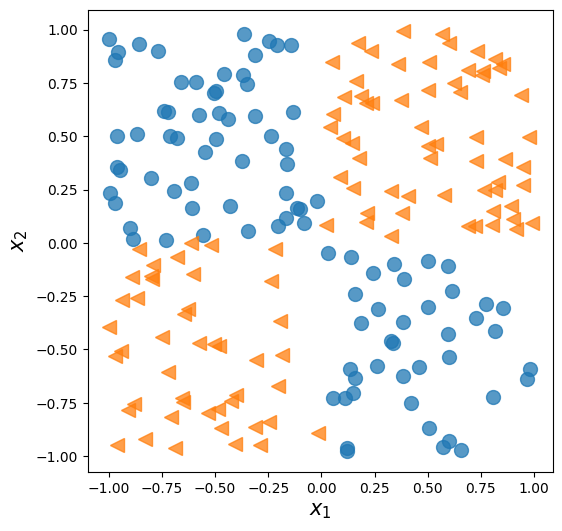

In [13]:
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(1)
np.random.seed(1)
x = np.random.uniform(low=-1, high=1, size=(200, 2))
y = np.ones(len(x))
y[x[:, 0] * x[:, 1] < 0] = 0
n_train = 100
x_train = torch.tensor(x[:n_train, :], dtype=torch.float32)
y_train = torch.tensor(y[:n_train], dtype=torch.float32)
x_valid = torch.tensor(x[n_train:, :], dtype=torch.float32)
y_valid = torch.tensor(y[n_train:], dtype=torch.float32)
fig = plt.figure(figsize=(6, 6))
plt.plot(x[y == 0, 0], x[y == 0, 1], 'o', alpha=0.75, markersize=10)
plt.plot(x[y == 1, 0], x[y == 1, 1], '<', alpha=0.75, markersize=10)
plt.xlabel(r'$x_1$', size=15)
plt.ylabel(r'$x_2$', size=15)
plt.show()

In [14]:
model = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)
model

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)

In [15]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

In [16]:
from torch.utils.data import DataLoader, TensorDataset

train_ds = TensorDataset(x_train, y_train)
batch_size = 2
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

In [17]:
torch.manual_seed(1)
num_epochs = 200


def train(model, num_epochs, train_dl, x_valid, y_valid):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs
    for epoch in range(num_epochs):
        for x_batch, y_batch in train_dl:
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_hist_train[epoch] += loss.item()
            is_correct = ((pred >= 0.5).float() == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.mean()
        loss_hist_train[epoch] /= n_train / batch_size
        accuracy_hist_train[epoch] /= n_train / batch_size
        pred = model(x_valid)[:, 0]
        loss = loss_fn(pred, y_valid)
        loss_hist_valid[epoch] += loss.item()
        is_correct = ((pred >= 0.5).float() == y_valid).float()
        accuracy_hist_valid[epoch] += is_correct.mean()
    return (loss_hist_train, loss_hist_valid,
            accuracy_hist_train, accuracy_hist_valid)


history = train(model, num_epochs, train_dl, x_valid, y_valid)

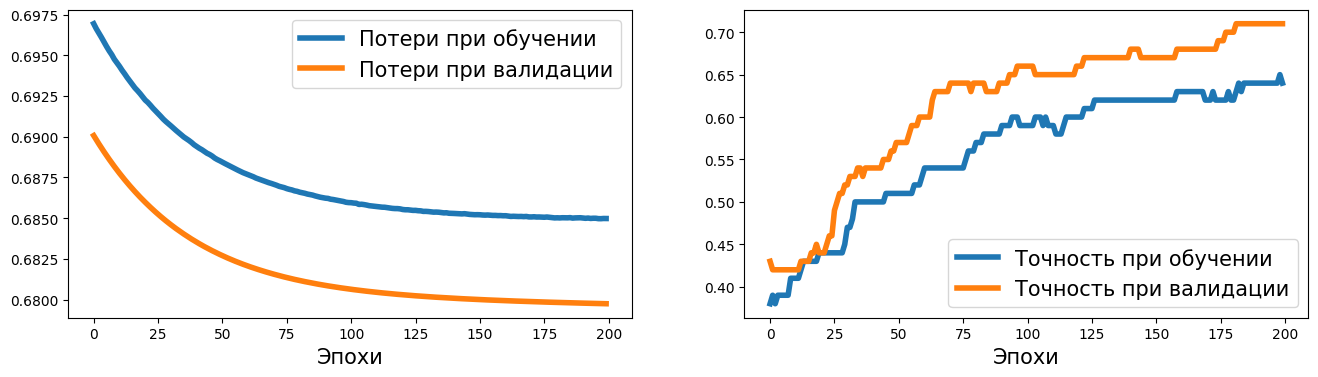

In [18]:
def plot_loss_acc(history):
    fig = plt.figure(figsize=(16, 4))
    ax = fig.add_subplot(1, 2, 1)
    plt.plot(history[0], lw=4)
    plt.plot(history[1], lw=4)
    plt.legend(['Потери при обучении', 'Потери при валидации'], fontsize=15)
    ax.set_xlabel('Эпохи', size=15)
    ax = fig.add_subplot(1, 2, 2)
    plt.plot(history[2], lw=4)
    plt.plot(history[3], lw=4)
    plt.legend(['Точность при обучении', 'Точность при валидации'], fontsize=15)
    ax.set_xlabel('Эпохи', size=15)


plot_loss_acc(history)

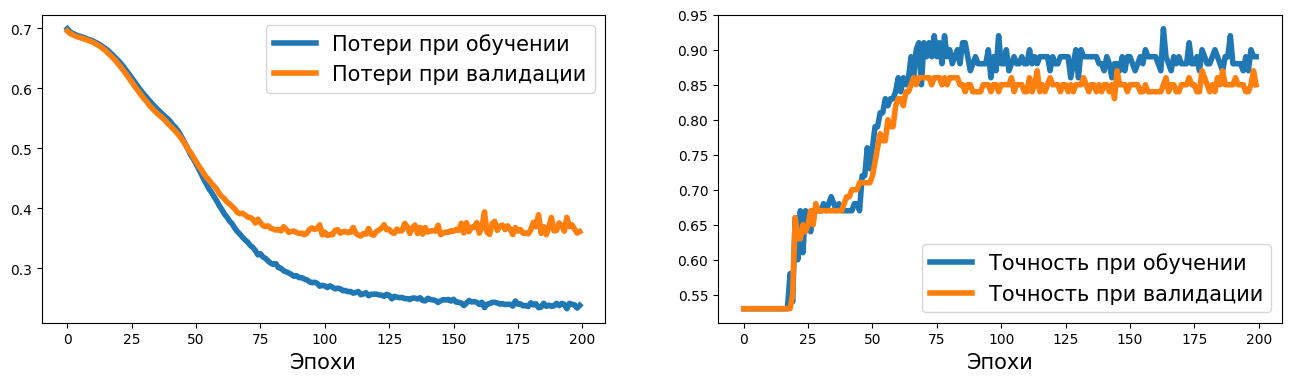

In [19]:
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)
history = train(model, num_epochs, train_dl, x_valid, y_valid)
plot_loss_acc(history)


In [20]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        l1 = nn.Linear(2, 4)
        a1 = nn.ReLU()
        l2 = nn.Linear(4, 4)
        a2 = nn.ReLU()
        l3 = nn.Linear(4, 1)
        a3 = nn.Sigmoid()
        l = [l1, a1, l2, a2, l3, a3]
        self.module_list = nn.ModuleList(l)

    def forward(self, x):
        for f in self.module_list:
            x = f(x)
        return x

    def predict(self, x):
        x = torch.tensor(x, dtype=torch.float32)
        pred = self.forward(x)[:, 0]
        return (pred >= 0.5).float()

In [21]:
model = MyModule()
model

MyModule(
  (module_list): ModuleList(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [22]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)
history = train(model, num_epochs, train_dl, x_valid, y_valid)

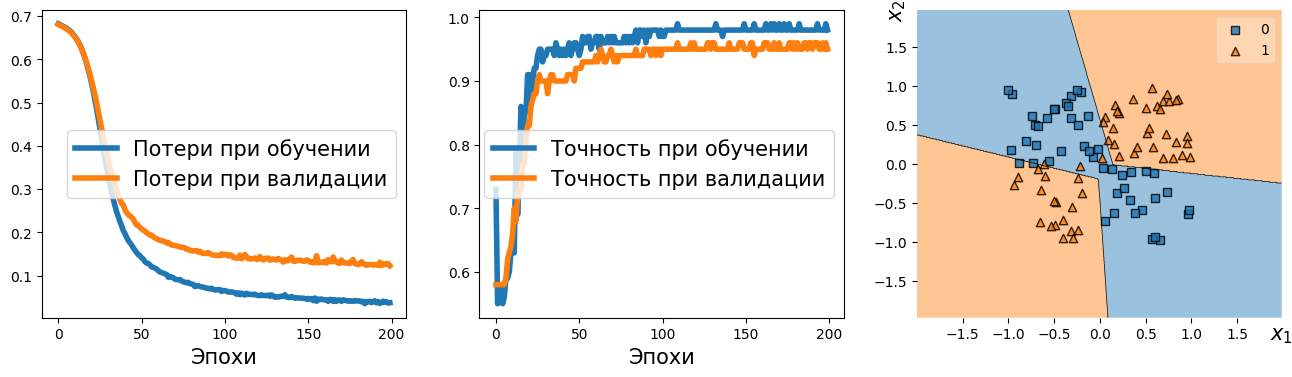

In [23]:
from mlxtend.plotting import plot_decision_regions

fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Потери при обучении', 'Потери при валидации'], fontsize=15)
ax.set_xlabel('Эпохи', size=15)
ax = fig.add_subplot(1, 3, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Точность при обучении', 'Точность при валидации'], fontsize=15)
ax.set_xlabel('Эпохи', size=15)
ax = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_valid.numpy(),
                      y=y_valid.numpy().astype(np.int_),
                      clf=model)
plt.xlabel(r'$x_1$', size=15)
ax.xaxis.set_label_coords(1, -0.025)
plt.ylabel(r'$x_2$', size=15)
ax.yaxis.set_label_coords(-0.025, 1)
plt.show()

In [24]:
class NoisyLayer(nn.Module):
    def __init__(self, input_size, output_size, noise_stddev=0.1):
        super().__init__()
        w = torch.Tensor(input_size, output_size)
        self.w = nn.Parameter(w)
        nn.init.xavier_uniform_(self.w)
        b = torch.Tensor(output_size).fill_(0)
        self.b = nn.Parameter(b)
        self.noise_stddev = noise_stddev

    def forward(self, x, training=False):
        if training:
            noise = torch.normal(.0, self.noise_stddev, x.shape)
            x_new = torch.add(x, noise)
        else:
            x_new = x
        return torch.add(torch.mm(x_new, self.w), self.b)

In [25]:
torch.manual_seed(1)
noisy_layer = NoisyLayer(4, 2)
x = torch.zeros((1, 4))
print(noisy_layer(x, training=True))
print(noisy_layer(x, training=True))
print(noisy_layer(x))

tensor([[ 0.1154, -0.0598]], grad_fn=<AddBackward0>)
tensor([[ 0.0432, -0.0375]], grad_fn=<AddBackward0>)
tensor([[0., 0.]], grad_fn=<AddBackward0>)


In [26]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = NoisyLayer(2, 4, 0.07)
        self.a1 = nn.ReLU()
        self.l2 = nn.Linear(4, 4)
        self.a2 = nn.ReLU()
        self.l3 = nn.Linear(4, 1)
        self.a3 = nn.Sigmoid()

    def forward(self, x, training=False):
        x = self.l1(x, training)
        x = self.a1(x)
        x = self.l2(x)
        x = self.a2(x)
        x = self.l3(x)
        x = self.a3(x)
        return x

    def predict(self, x):
        x = torch.tensor(x, dtype=torch.float32)
        pred = self.forward(x)[:, 0]
        return (pred >= 0.5).float()

In [27]:
torch.manual_seed(1)
model = MyModule()
model

MyModule(
  (l1): NoisyLayer()
  (a1): ReLU()
  (l2): Linear(in_features=4, out_features=4, bias=True)
  (a2): ReLU()
  (l3): Linear(in_features=4, out_features=1, bias=True)
  (a3): Sigmoid()
)

In [28]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)
torch.manual_seed(1)
loss_hist_train = [0] * num_epochs
accuracy_hist_train = [0] * num_epochs
loss_hist_valid = [0] * num_epochs
accuracy_hist_valid = [0] * num_epochs
for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch, True)[:, 0]
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_hist_train[epoch] += loss.item()
        is_correct = ((pred >= 0.5).float() == y_batch).float()
        accuracy_hist_train[epoch] += is_correct.mean()
    loss_hist_train[epoch] /= n_train / batch_size
    accuracy_hist_train[epoch] /= n_train / batch_size
    pred = model(x_valid)[:, 0]
    loss = loss_fn(pred, y_valid)
    loss_hist_valid[epoch] += loss.item()
    is_correct = ((pred >= 0.5).float() == y_valid).float()
    accuracy_hist_valid[epoch] += is_correct.mean()

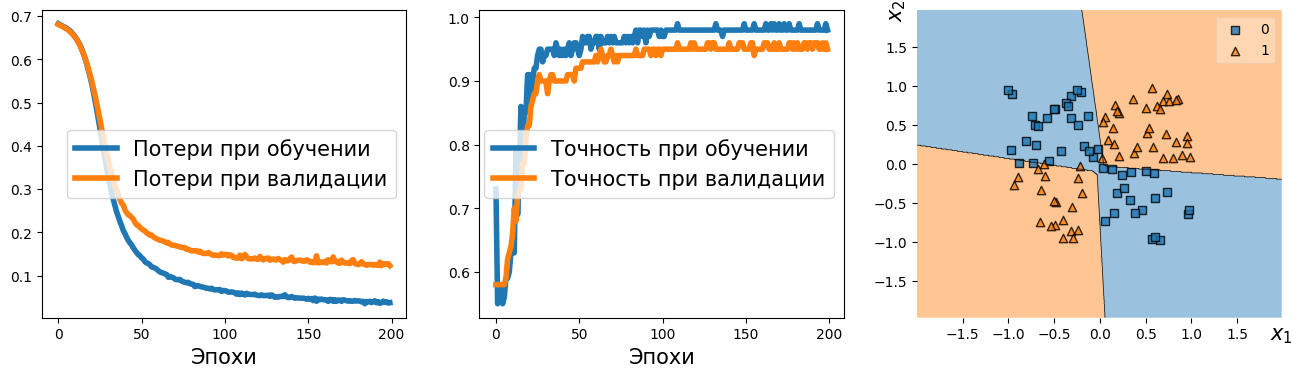

In [29]:
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Потери при обучении', 'Потери при валидации'], fontsize=15)
ax.set_xlabel('Эпохи', size=15)
ax = fig.add_subplot(1, 3, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Точность при обучении', 'Точность при валидации'], fontsize=15)
ax.set_xlabel('Эпохи', size=15)
ax = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_valid.numpy(),
                      y=y_valid.numpy().astype(np.int_),
                      clf=model)
plt.xlabel(r'$x_1$', size=15)
ax.xaxis.set_label_coords(1, -0.025)
plt.ylabel(r'$x_2$', size=15)
ax.yaxis.set_label_coords(-0.025, 1)
plt.show()

In [30]:
import pandas as pd
import numpy as np

columns_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year', 'Origin']
df = pd.read_csv('auto-mpg.data', names=columns_names, na_values='?', comment='\t', sep=" ", skipinitialspace=True)

df = df.dropna()
df = df.reset_index(drop=True)

from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df, train_size=.8, random_state=1)
df_train['Cylinders'] = df_train['Cylinders'].astype(np.float64)
df_test['Cylinders'] = df_test['Cylinders'].astype(np.float64)

train_stats = df_train.describe().transpose()
numeric_column_names = [
    'Cylinders', 'Displacement',
    'Horsepower', 'Weight', 'Acceleration'
]
df_train_norm, df_test_norm = df_train.copy(), df_test.copy()
for col_name in numeric_column_names:
    mean = train_stats.loc[col_name, 'mean']
    std = train_stats.loc[col_name, 'std']
    df_train_norm.loc[:, col_name] = \
        (df_train_norm.loc[:, col_name].astype(np.float32) - mean) / std
    df_test_norm.loc[:, col_name] = \
        (df_test_norm.loc[:, col_name].astype(np.float32) - mean) / std
df_train_norm.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
203,28.0,-0.824303,-0.901020,-0.736562,-0.950031,0.255202,76,3
255,19.4,0.351127,0.413800,-0.340982,0.293190,0.548737,78,1
72,13.0,1.526556,1.144256,0.713897,1.339617,-0.625403,72,1
235,30.5,-0.824303,-0.891280,-1.053025,-1.072585,0.475353,77,1
37,14.0,1.526556,1.563051,1.636916,1.470420,-1.359240,71,1


In [31]:
boundaries = torch.tensor([73, 76, 79])
v = torch.tensor(df_train_norm['Model Year'].values)
df_train_norm['Model Year Bucketed'] = torch.bucketize(
    v, boundaries, right=True
)
v = torch.tensor(df_test_norm['Model Year'].values)
df_test_norm['Model Year Bucketed'] = torch.bucketize(
    v, boundaries, right=True
)
numeric_column_names.append('Model Year Bucketed')


In [32]:
from torch.nn.functional import one_hot

total_origin = len(set(df_train_norm['Origin']))
origin_encoded = one_hot(torch.from_numpy(
    df_train_norm['Origin'].values) % total_origin)
x_train_numeric = torch.tensor(
    df_train_norm[numeric_column_names].values
)
x_train = torch.cat([x_train_numeric, origin_encoded], 1).float()
origin_encoded = one_hot(torch.from_numpy(
    df_test_norm['Origin'].values) % total_origin)
x_test_numeric = torch.tensor(
    df_test_norm[numeric_column_names].values
)
x_test = torch.cat([x_test_numeric, origin_encoded], 1).float()

C:\Users\perev\AppData\Local\Temp\ipykernel_24692\2285538267.py:4: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  origin_encoded = one_hot(torch.from_numpy(


In [33]:
y_train = torch.tensor(df_train_norm['MPG'].values).float()
y_test = torch.tensor(df_test_norm['MPG'].values).float()

In [34]:
train_ds = TensorDataset(x_train, y_train)
batch_size = 8
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size, shuffle=True)
hidden_units = [8, 4]
input_size = x_train.shape[1]
all_layers = []
for hidden_unit in hidden_units:
    layer = nn.Linear(input_size, hidden_unit)
    all_layers.append(layer)
    all_layers.append(nn.ReLU())
    input_size = hidden_unit
all_layers.append(nn.Linear(input_size, 1))
model = nn.Sequential(*all_layers)
model

Sequential(
  (0): Linear(in_features=9, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=1, bias=True)
)

In [35]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)


In [36]:
torch.manual_seed(1)
num_epochs = 200
log_epochs = 20
for epoch in range(num_epochs):
    loss_hist_train = 0
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)[:, 0]
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_hist_train += loss.item()
    if epoch % log_epochs == 0:
        print(f"Эпоха {epoch} "
              f"Потеря {loss_hist_train / len(train_dl):.4f}")

Эпоха 0 Потеря 536.1047
Эпоха 20 Потеря 8.4361
Эпоха 40 Потеря 7.8695
Эпоха 60 Потеря 7.1891
Эпоха 80 Потеря 6.7064
Эпоха 100 Потеря 6.7603
Эпоха 120 Потеря 6.3107
Эпоха 140 Потеря 6.6884
Эпоха 160 Потеря 6.7549
Эпоха 180 Потеря 6.2029


In [37]:
with torch.no_grad():
    pred = model(x_test.float())[:, 0]
    loss = loss_fn(pred, y_test)
    print(f'MSE при тестировании {loss.item():.4f}')
    print(f"MAE при тестировании {nn.L1Loss()(pred, y_test).item():.4f}")

MSE при тестировании 9.5907
MAE при тестировании 2.1177


In [38]:
import torchvision
from torchvision import transforms

image_path = './'
transform = transforms.Compose([transforms.ToTensor(), ])

mnist_train_dataset = torchvision.datasets.MNIST(
    root=image_path, train=True,
    transform=transform, download=True,
)

mnist_test_dataset = torchvision.datasets.MNIST(
    root=image_path, train=False,
    transform=transform, download=False
)
batch_size = 64
torch.manual_seed(1)
train_dl = DataLoader(mnist_train_dataset, batch_size, shuffle=True)

In [39]:
hidden_units = [32, 16]
image_size = mnist_train_dataset[0][0].shape
input_size = image_size[0] * image_size[1] * image_size[2]

all_layers = [nn.Flatten()]
for hidden_unit in hidden_units:
    layer = nn.Linear(input_size, hidden_unit)
    all_layers.append(layer)
    all_layers.append(nn.ReLU())
    input_size = hidden_unit

all_layers.append(nn.Linear(hidden_units[-1], 10))
model = nn.Sequential(*all_layers)

model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=32, bias=True)
  (2): ReLU()
  (3): Linear(in_features=32, out_features=16, bias=True)
  (4): ReLU()
  (5): Linear(in_features=16, out_features=10, bias=True)
)

In [40]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

torch.manual_seed(1)
num_epochs = 20
for epoch in range(num_epochs):
    accuracy_hist_train = 0

    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
        accuracy_hist_train += is_correct.sum()
    accuracy_hist_train /= len(train_dl.dataset)
    print(f'Эпоха {epoch}'
          f' Точность {accuracy_hist_train:.4f}')

Эпоха 0 Точность 0.8531


KeyboardInterrupt: 

In [298]:
pred = model(mnist_test_dataset.data / 255.)
is_correct = (torch.argmax(pred, dim=1) == mnist_test_dataset.targets).float()
print(f'Test accuracy: {is_correct.mean():.4f}')

Test accuracy: 0.9653


In [41]:
import pytorch_lightning as pl
import torch
import torch.nn as nn

from torchmetrics import Accuracy

In [51]:
class MultiLayerPerceptron(pl.LightningModule):
    def __init__(self, image_shape=(1, 28, 28), hidden_units=(32, 16)):
        super().__init__()

        self.train_acc = Accuracy(task="multiclass", num_classes=10)
        self.valid_acc = Accuracy(task="multiclass", num_classes=10)
        self.test_acc = Accuracy(task="multiclass", num_classes=10)

        # Model similar to previous section:
        input_size = image_shape[0] * image_shape[1] * image_shape[2]
        all_layers = [nn.Flatten()]
        for hidden_unit in hidden_units:
            layer = nn.Linear(input_size, hidden_unit)
            all_layers.append(layer)
            all_layers.append(nn.ReLU())
            input_size = hidden_unit

        all_layers.append(nn.Linear(hidden_units[-1], 10))
        self.model = nn.Sequential(*all_layers)

    def forward(self, x):
        x = self.model(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = nn.functional.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.train_acc.update(preds, y)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", self.train_acc.compute(), prog_bar=True)
        return loss

    def on_training_epoch_end(self):
        self.log("train_acc", self.train_acc.compute())
        self.train_acc.reset()

    def on_validation_epoch_end(self):
        self.log("valid_acc", self.valid_acc.compute())
        self.valid_acc.reset()

    def on_test_epoch_end(self):
        self.log("valid_acc", self.valid_acc.compute())
        self.valid_acc.reset()

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = nn.functional.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.test_acc.update(preds, y)
        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", self.test_acc.compute(), prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.001)
        return optimizer

In [52]:
from torch.utils.data import DataLoader
from torch.utils.data import random_split

from torchvision.datasets import MNIST
from torchvision import transforms

In [53]:
class MnistDataModule(pl.LightningDataModule):
    def __init__(self, data_path='./'):
        super().__init__()
        self.data_path = data_path
        self.transform = transforms.Compose([transforms.ToTensor()])

    def prepare_data(self):
        MNIST(root=self.data_path, download=True)

    def setup(self, stage=None):
        # stage is either 'fit', 'validate', 'test', or 'predict'
        # here note relevant
        mnist_all = MNIST(
            root=self.data_path,
            train=True,
            transform=self.transform,
            download=False
        )

        self.train, self.val = random_split(
            mnist_all, [55000, 5000], generator=torch.Generator().manual_seed(1)
        )

        self.test = MNIST(
            root=self.data_path,
            train=False,
            transform=self.transform,
            download=False
        )

    def train_dataloader(self):
        return DataLoader(self.train, batch_size=64, num_workers=4)

    def val_dataloader(self):
        return DataLoader(self.val, batch_size=64, num_workers=4)

    def test_dataloader(self):
        return DataLoader(self.test, batch_size=64, num_workers=4)


torch.manual_seed(1)
mnist_dm = MnistDataModule()

In [54]:
from pytorch_lightning.loggers import TensorBoardLogger


mnistclassifier = MultiLayerPerceptron()
logger = TensorBoardLogger("./")
if torch.cuda.is_available():  # if you have GPUs
    trainer = pl.Trainer(logger=logger, max_epochs=10, accelerator='gpu', devices=-1)
else:
    trainer = pl.Trainer(logger=logger, max_epochs=10)
print(trainer.logger.log_dir)
trainer.fit(model=mnistclassifier, datamodule=mnist_dm)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
C:\Users\perev\PycharmProjects\machine_learning_book\.venv\Lib\site-packages\pytorch_lightning\trainer\configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | train_acc | MulticlassAccuracy | 0      | train | 0    
1 | valid_acc | MulticlassAccuracy | 0 

./lightning_logs\version_0
Epoch 9: 100%|██████████| 860/860 [00:24<00:00, 35.30it/s, v_num=0, train_loss=0.260, train_acc=0.945]  

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 860/860 [00:24<00:00, 35.28it/s, v_num=0, train_loss=0.260, train_acc=0.945]


In [55]:
trainer.test(model=mnistclassifier, datamodule=mnist_dm)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\perev\PycharmProjects\machine_learning_book\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\perev\PycharmProjects\machine_learning_book\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'test_dataloader' to speed up the dataloader worker initialization.


Testing DataLoader 0: 100%|██████████| 157/157 [00:00<00:00, 157.43it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9505840539932251
        test_loss           0.14711591601371765
        valid_acc                   0.0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


C:\Users\perev\PycharmProjects\machine_learning_book\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: The ``compute`` method of metric MulticlassAccuracy was called before the ``update`` method which may lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)


[{'test_loss': 0.14711591601371765,
  'test_acc': 0.9505840539932251,
  'valid_acc': 0.0}]

In [49]:
%load_ext tensorboard
%tensorboard --logdir=lightning_logs/